In [ ]:
import numpy as np

class IndirectSurvey:
    def __init__(self):
        # 頂点座標の定義
        self.points = {
            'A': np.array([-1, 1]),
            'B': np.array([1, 1]),
            'C': np.array([0, 0]),
            'D': np.array([-1, -1]),
            'E': np.array([1, -1])
        }
        self.pairs = [
            ('A', 'B'), ('A', 'C'), ('A', 'D'), ('A', 'E'),
            ('B', 'C'), ('B', 'D'), ('B', 'E'),
            ('C', 'D'), ('C', 'E'), ('D', 'E')
        ]

    def get_distribution(self, x, y):
        Q = np.array([x, y])
        results = {}

        for p1_key, p2_key in self.pairs:
            p1 = self.points[p1_key]
            p2 = self.points[p2_key]

            # 投影係数 t の計算
            v = p2 - p1
            t = np.dot(Q - p1, v) / np.dot(v, v)

            # Cが絡む特殊ルールとクランプ処理
            if p2_key == 'C' and t > 1.0:
                w = 1.0
            else:
                w = np.clip(t, 0.0, 1.0)

            results[f"{p1_key}-{p2_key}"] = w

        return results

# 使用例
survey = IndirectSurvey()
ratios = survey.get_distribution(0.5, 0.2)
print(ratios)

{'A-B': np.float64(0.75), 'A-C': 1.0, 'A-D': np.float64(0.4), 'A-E': np.float64(0.575), 'B-C': np.float64(0.65), 'B-D': np.float64(0.325), 'B-E': np.float64(0.4), 'C-D': np.float64(0.0), 'C-E': np.float64(0.15), 'D-E': np.float64(0.75)}


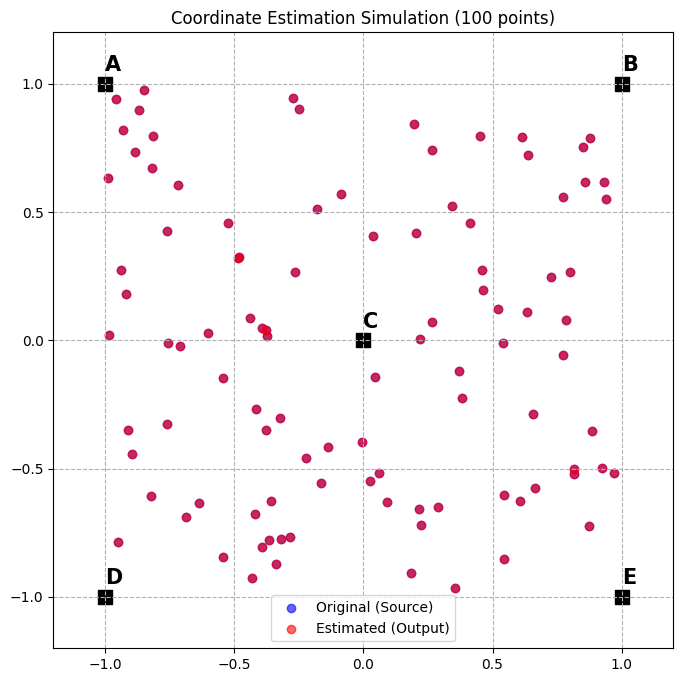

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_survey():
    # 頂点座標の定義
    pts = {
        'A': np.array([-1, 1]), 'B': np.array([1, 1]), 'C': np.array([0, 0]),
        'D': np.array([-1, -1]), 'E': np.array([1, -1])
    }
    pairs = [
        ('A', 'B'), ('A', 'C'), ('A', 'D'), ('A', 'E'),
        ('B', 'C'), ('B', 'D'), ('B', 'E'),
        ('C', 'D'), ('C', 'E'), ('D', 'E')
    ]

    # 1. ランダムに100点の元の座標 (x, y) を生成
    np.random.seed(42)
    original_points = np.random.uniform(-1, 1, (100, 2))
    estimated_points = []

    for Q in original_points:
        # 2. ロジックに基づいて各ペアの分配比(w)を計算
        scores = {'A': 0, 'B': 0, 'C': 0, 'D': 0, 'E': 0}

        for p1_key, p2_key in pairs:
            p1, p2 = pts[p1_key], pts[p2_key]
            v = p2 - p1
            t = np.dot(Q - p1, v) / np.dot(v, v)

            # Cが絡む特殊ルール（逆側ならCに1）
            if p2_key == 'C' and t > 1.0:
                w = 1.0
            elif p1_key == 'C' and t < 0.0: # P1がCの場合の逆側判定
                w = 0.0
            else:
                w = np.clip(t, 0.0, 1.0)

            # スコアの加算
            scores[p1_key] += (1 - w)
            scores[p2_key] += w

        # 3. 推定式を用いて座標を復元
        # x = (B+E - A-D) / total, y = (A+B - D-E) / total
        total = sum(scores.values())
        #x_hat = (scores['B'] + scores['E'] - scores['A'] - scores['D']) / total
        #y_hat = (scores['A'] + scores['B'] - scores['D'] - scores['E']) / total
        x_hat = ((scores['B'] + scores['E'] - scores['A'] - scores['D']) / total) * 2.5
        y_hat = ((scores['A'] + scores['B'] - scores['D'] - scores['E']) / total) * 2.5

# 2倍にすると -1 ~ 1 を超える可能性があるため、最後にはみ出しをカットします
        x_hat = np.clip(x_hat, -1.0, 1.0)
        y_hat = np.clip(y_hat, -1.0, 1.0)
        estimated_points.append([x_hat, y_hat])

    estimated_points = np.array(estimated_points)

    # 4. グラフ表示
    plt.figure(figsize=(8, 8))
    # 頂点のプロット
    for k, v in pts.items():
        plt.scatter(v[0], v[1], c='black', marker='s', s=100)
        plt.text(v[0], v[1]+0.05, k, fontsize=15, fontweight='bold')

    # 元の点と推定点のプロット
    for i in range(len(original_points)):
        # 元の点(青)から推定点(赤)へ線を引く
        plt.plot([original_points[i,0], estimated_points[i,0]],
                 [original_points[i,1], estimated_points[i,1]], 'gray', alpha=0.3)

    plt.scatter(original_points[:,0], original_points[:,1], c='blue', label='Original (Source)', alpha=0.6)
    plt.scatter(estimated_points[:,0], estimated_points[:,1], c='red', label='Estimated (Output)', alpha=0.6)

    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.grid(True, linestyle='--')
    plt.legend()
    plt.title("Coordinate Estimation Simulation (100 points)")
    plt.show()

simulate_survey()

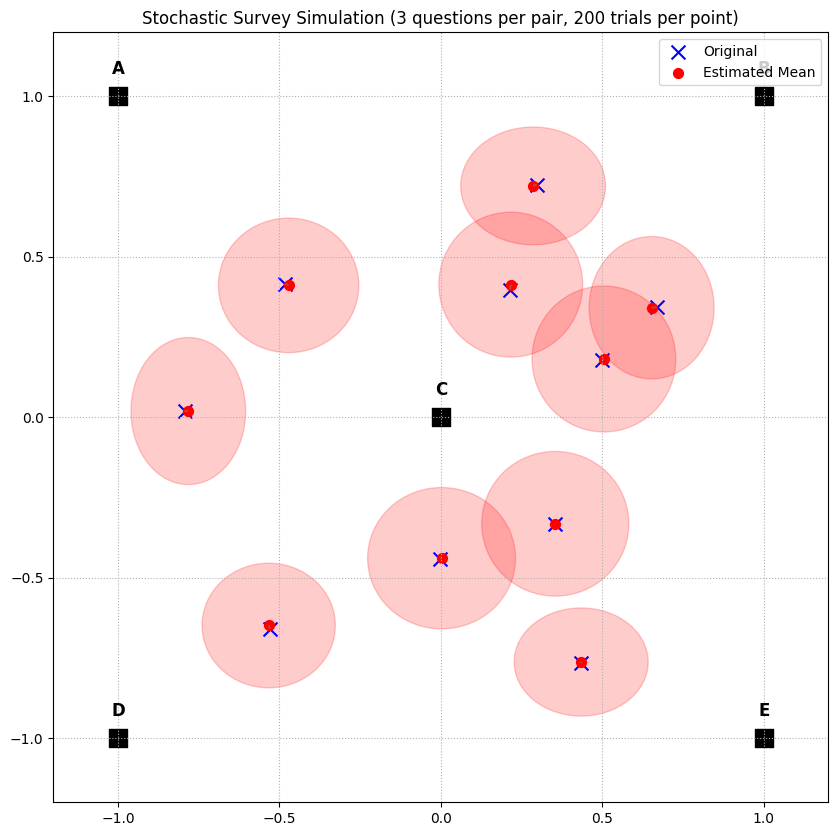

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def run_stochastic_simulation():
    # 頂点座標の定義
    pts = {
        'A': np.array([-1, 1]), 'B': np.array([1, 1]), 'C': np.array([0, 0]),
        'D': np.array([-1, -1]), 'E': np.array([1, -1])
    }
    pairs = [
        ('A', 'B'), ('A', 'C'), ('A', 'D'), ('A', 'E'),
        ('B', 'C'), ('B', 'D'), ('B', 'E'),
        ('C', 'D'), ('C', 'E'), ('D', 'E')
    ]

    # 1. 10種類のランダムな(x,y)を生成
    np.random.seed(10)
    test_points = np.random.uniform(-0.8, 0.8, (10, 2))

    fig, ax = plt.subplots(figsize=(10, 10))

    for original_q in test_points:
        estimates = []
        for _ in range(1000):  # 200回のアンケート
            scores = {k: 0.0 for k in pts.keys()}

            for p1_key, p2_key in pairs:
                p1, p2 = pts[p1_key], pts[p2_key]
                v = p2 - p1
                t = np.dot(original_q - p1, v) / np.dot(v, v)

                # Cの特殊ルール
                if p2_key == 'C' and t > 1.0:
                    w_prob = 1.0
                elif p1_key == 'C' and t < 0.0:
                    w_prob = 0.0
                else:
                    w_prob = np.clip(t, 0.0, 1.0)

                # 3問ずつの確率的回答 (1がP2選択, 0がP1選択)
                # w_probを確率として、3回の平均を今回のペアのスコアとする
                answers = np.random.binomial(n=1, p=w_prob, size=5)
                w_score = np.mean(answers)

                scores[p1_key] += (1 - w_score)
                scores[p2_key] += w_score

            # 確定した推定式 (k=2.5)
            total = sum(scores.values())
            raw_x = 2.5 * (scores['B'] + scores['E'] - scores['A'] - scores['D']) / total
            raw_y = 2.5 * (scores['A'] + scores['B'] - scores['D'] - scores['E']) / total
            estimates.append([np.clip(raw_x, -1, 1), np.clip(raw_y, -1, 1)])

        estimates = np.array(estimates)
        mean_x, mean_y = np.mean(estimates, axis=0)
        std_x, std_y = np.std(estimates, axis=0)

        # 楕円の描画 (1標準偏差)
        ellipse = Ellipse((mean_x, mean_y), width=std_x*2, height=std_y*2,
                          alpha=0.2, color='red', zorder=1)
        ax.add_patch(ellipse)

        # プロット
        ax.scatter(original_q[0], original_q[1], color='blue', marker='x', s=100, label='Original' if 'Original' not in ax.get_legend_handles_labels()[1] else "")
        ax.scatter(mean_x, mean_y, color='red', s=50, label='Estimated Mean' if 'Estimated Mean' not in ax.get_legend_handles_labels()[1] else "")
        ax.plot([original_q[0], mean_x], [original_q[1], mean_y], 'gray', linestyle='--', alpha=0.5)

    # 補助線の描画
    for k, v in pts.items():
        ax.scatter(v[0], v[1], c='black', marker='s', s=150)
        ax.text(v[0], v[1]+0.07, k, ha='center', fontsize=12, fontweight='bold')

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.grid(True, linestyle=':')
    ax.set_title("Stochastic Survey Simulation (3 questions per pair, 200 trials per point)")
    ax.legend(loc='upper right')
    plt.show()

run_stochastic_simulation()